In [1]:
from hubble_utils import load_agn_data
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress

plt.style.use('style.mplstyle')

In [2]:
lambda_pivot = {
    'u': 3543,  # SDSS u-band
    'g': 4770,  # SDSS g-band
    'r': 6231,  # SDSS r-band
    'i': 7625,  # SDSS i-band
    'z': 9134,  # SDSS z-band
    'y': 9633,  # PS1 y-band
}

colors = {
    'u': 'tab:blue',
    'g': 'tab:green', 
    'r': 'tab:orange', 
    'i': 'tab:red', 
    'z': 'tab:brown', 
    'y': 'tab:gray'
}

agn_df = load_agn_data("results/data/sep1_chisq_alphalamcsv_nobwb_poly1_N20w4000s1000t8c4_fittedm2500_twice.h5", populate_sdss=False, apply_cut=False)

Reading quasars from HDF5: 100%|██████████| 4000/4000 [00:17<00:00, 224.74it/s]


Number of quasars loaded: 4000
spectra_fit_csv not provided, assuming alpha_lambda is in agn h5 file
[WARNING] cov_log_sigma_UV_log_tau_UV_RF not in data, setting to 0.0
Number of quasars with 0 < z <= 1.0: 989
Number of quasars with z > 3: 116
Highest redshift quasar: 4.32306007971774
Columns with NaNs: ['apparent_mag_g', 'apparent_mag_g_err', 'apparent_mag_i', 'apparent_mag_i_err', 'apparent_mag_i_obs', 'apparent_mag_r', 'apparent_mag_r_err', 'apparent_mag_u', 'apparent_mag_u_err', 'apparent_mag_z', 'apparent_mag_z_err']
Skipping data cuts as apply_cut is False.


In [8]:
# Calculate and print slopes for sigma and tau panels
def get_slope(x, y, n_bins=12):
    mask = np.isfinite(x) & np.isfinite(y)
    x, y = x[mask], y[mask]
    if len(x) == 0:
        return np.nan
    xb = np.linspace(x.min(), x.max(), n_bins+1)
    xc = 0.5*(xb[:-1] + xb[1:])
    ymed = []
    for i in range(n_bins):
        m = (x >= xb[i]) & (x < xb[i+1])
        if m.sum() < 5:
            ymed.append(np.nan)
        else:
            ymed.append(np.nanpercentile(y[m], 50))
    xc = xc[np.isfinite(ymed)]
    ymed = np.array(ymed)[np.isfinite(ymed)]
    if len(xc) > 2:
        slope, intercept, *_ = linregress(xc, ymed)
        return slope
    return np.nan

# Gather all points for sigma
x_all_sigma, y_all_sigma = [], []
for b in ('u', 'g', 'r', 'i', 'z'):
    lam_rf = lambda_pivot[b] / (1.0 + agn_df['z'].to_numpy())
    log_lam_rf = np.log10(lam_rf)
    log_sigma  = agn_df[f'log_sigma_band_{b}'].to_numpy()
    mask = np.isfinite(log_lam_rf) & np.isfinite(log_sigma)
    x_all_sigma.append(log_lam_rf[mask])
    y_all_sigma.append(log_sigma[mask])
x_all_sigma = np.concatenate(x_all_sigma)
y_all_sigma = np.concatenate(y_all_sigma)

# Gather all points for tau
x_all_tau, y_all_tau = [], []
for b in ('u', 'g', 'r', 'i', 'z'):
    lam_rf = lambda_pivot[b] / (1.0 + agn_df['z'].to_numpy())
    log_lam_rf = np.log10(lam_rf)
    log_tau    = agn_df[f'log_tau_band_{b}_RF'].to_numpy() - agn_df[f'log_tau_UV_RF'].to_numpy()
    mask = np.isfinite(log_lam_rf) & np.isfinite(log_tau)
    x_all_tau.append(log_lam_rf[mask])
    y_all_tau.append(log_tau[mask])
x_all_tau = np.concatenate(x_all_tau)
y_all_tau = np.concatenate(y_all_tau)

slope_sigma = get_slope(x_all_sigma, y_all_sigma)
slope_tau = get_slope(x_all_tau, y_all_tau)

print(f"Slope for log_sigma vs log_lambda_RF: {slope_sigma:.4f}")
print(f"Slope for log_tau vs log_lambda_RF:   {slope_tau:.4f}")


Slope for log_sigma vs log_lambda_RF: -0.3265
Slope for log_tau vs log_lambda_RF:   -0.5451


/tmp/ipykernel_884418/5268078.py:92: RuntimeWarning: divide by zero encountered in log10
  return np.log10(x)


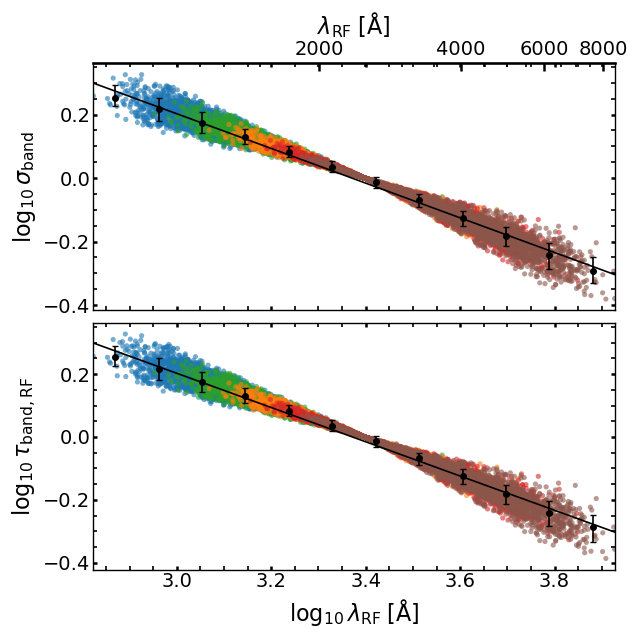

(<Figure size 620x620 with 2 Axes>,
 (<Axes: ylabel='$\\log_{10}\\sigma_{\\mathrm{band}}$'>,
  <Axes: xlabel='$\\log_{10}\\lambda_{\\mathrm{RF}}\\;[\\mathrm{\\AA}]$', ylabel='$\\log_{10}\\tau_{\\mathrm{band,RF}}$'>))

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

def plot_sigma_tau_vs_lambda(df, bands=('u', 'g', 'r', 'i', 'z'), n_bins=12, show=True):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6.2, 6.2), constrained_layout=True, sharex=True)
    fig.set_constrained_layout_pads(w_pad=0.01, h_pad=0.01, wspace=0.01, hspace=0.02)

    def inward_axes(ax):
        ax.tick_params(direction='in', which='both', top=True, right=True, length=3, pad=2)
        for s in ax.spines.values():
            s.set_linewidth(1.0)

    def bin_stats(x, y, n_bins):
        mask = np.isfinite(x) & np.isfinite(y)
        x, y = x[mask], y[mask]
        if len(x) == 0:
            return np.array([]), np.array([]), np.array([]), np.array([])
        xb = np.linspace(x.min(), x.max(), n_bins+1)
        xc = 0.5*(xb[:-1] + xb[1:])
        ymed, ylo, yhi = [], [], []
        for i in range(n_bins):
            m = (x >= xb[i]) & (x < xb[i+1])
            if m.sum() < 5:
                ymed.append(np.nan); ylo.append(np.nan); yhi.append(np.nan)
            else:
                q16, q50, q84 = np.nanpercentile(y[m], [16, 50, 84])
                ymed.append(q50); ylo.append(q50 - q16); yhi.append(q84 - q50)
        return xc, np.array(ymed), np.array(ylo), np.array(yhi)

    # Collect all points for common x-limits
    x_all_sigma, y_all_sigma = [], []
    x_all_tau,   y_all_tau   = [], []

    # Top panel scatter
    for b in bands:
        lam_rf = lambda_pivot[b] / (1.0 + df['z'].to_numpy())
        log_lam_rf = np.log10(lam_rf)
        log_sigma  = df[f'log_sigma_band_{b}'].to_numpy() - df[f'log_sigma_UV'].to_numpy()
        mask = np.isfinite(log_lam_rf) & np.isfinite(log_sigma)
        ax1.scatter(log_lam_rf[mask], log_sigma[mask], s=14, alpha=0.6,
                    color=colors[b], edgecolor='none', zorder=1)
        x_all_sigma.append(log_lam_rf[mask])
        y_all_sigma.append(log_sigma[mask])

    # Bottom panel scatter
    for b in bands:
        lam_rf = lambda_pivot[b] / (1.0 + df['z'].to_numpy())
        log_lam_rf = np.log10(lam_rf)
        log_tau    = df[f'log_tau_band_{b}_RF'].to_numpy() - df[f'log_tau_UV_RF'].to_numpy()
        mask = np.isfinite(log_lam_rf) & np.isfinite(log_tau)
        ax2.scatter(log_lam_rf[mask], log_tau[mask], s=14, alpha=0.6,
                    color=colors[b], edgecolor='none', zorder=1)
        x_all_tau.append(log_lam_rf[mask])
        y_all_tau.append(log_tau[mask])

    # Binned medians for sigma
    x_all_sigma = np.concatenate(x_all_sigma)
    y_all_sigma = np.concatenate(y_all_sigma)
    xc, ymed, ylo, yhi = bin_stats(x_all_sigma, y_all_sigma, n_bins)
    ok = np.isfinite(ymed)
    ax1.errorbar(xc[ok], ymed[ok], yerr=[ylo[ok], yhi[ok]], fmt='o', color='k',
                 ms=4, lw=1.2, capsize=2.5, zorder=3)
    if ok.sum() > 2:
        slope, intercept, *_ = linregress(xc[ok], ymed[ok])
        xfit = np.linspace(np.nanmin(x_all_sigma), np.nanmax(x_all_sigma), 200)
        ax1.plot(xfit, slope*xfit + intercept, color='k', lw=1.2, zorder=2)

    # Binned medians for tau
    x_all_tau = np.concatenate(x_all_tau)
    y_all_tau = np.concatenate(y_all_tau)
    xc, ymed, ylo, yhi = bin_stats(x_all_tau, y_all_tau, n_bins)
    ok = np.isfinite(ymed)
    ax2.errorbar(xc[ok], ymed[ok], yerr=[ylo[ok], yhi[ok]], fmt='o', color='k',
                 ms=4, lw=1.2, capsize=2.5, zorder=3)
    if ok.sum() > 2:
        slope, intercept, *_ = linregress(xc[ok], ymed[ok])
        xfit = np.linspace(np.nanmin(x_all_tau), np.nanmax(x_all_tau), 200)
        ax2.plot(xfit, slope*xfit + intercept, color='k', lw=1.2, zorder=2)

    # Labels and style
    ax1.set_ylabel(r'$\log_{10}\sigma_{\mathrm{band}}$')
    ax2.set_ylabel(r'$\log_{10}\tau_{\mathrm{band,RF}}$')
    ax2.set_xlabel(r'$\log_{10}\lambda_{\mathrm{RF}}\;[\mathrm{\AA}]$')
    inward_axes(ax1)
    inward_axes(ax2)

    # Top axis in wavelength (Å) with dynamically chosen nice ticks
    def loglam_to_angstrom(x):
        return 10**x
    def angstrom_to_loglam(x):
        return np.log10(x)

    secax = ax1.secondary_xaxis('top', functions=(loglam_to_angstrom, angstrom_to_loglam))
    secax.set_xlabel(r'$\lambda_{\mathrm{RF}}\;[\mathrm{\AA}]$')
    secax.tick_params(direction='in', which='both', top=True)

    # Determine tick step dynamically
    lam_min = 10**np.nanmin(x_all_sigma)
    lam_max = 10**np.nanmax(x_all_sigma)
    lam_range = lam_max - lam_min

    # choose step from [100, 200, 500, 1000] Å
    possible_steps = np.array([100, 200, 500, 1000, 2000])
    step = possible_steps[np.argmin(np.abs(lam_range / possible_steps - 4))]  # aim for ~4 ticks
    tick_vals = np.arange(np.floor(lam_min / step) * step,
                          np.ceil(lam_max / step) * step + step, step)
    secax.set_xticks(tick_vals)

    ax2.set_xlim(np.nanmin(x_all_sigma), np.nanmax(x_all_sigma))

    

    if show:
        plt.show()
    return fig, (ax1, ax2)


plot_sigma_tau_vs_lambda(agn_df)

/tmp/ipykernel_1029273/2043384156.py:173: RuntimeWarning: divide by zero encountered in log10
  def A_to_loglam(x): return np.log10(x)


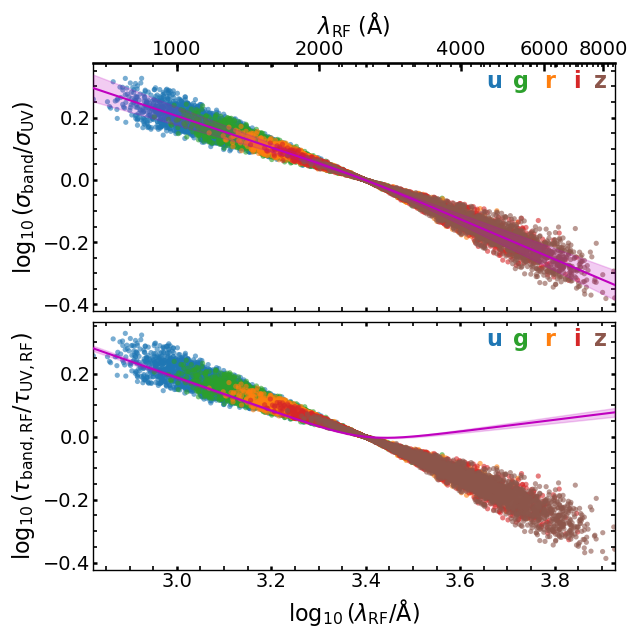

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress


# --- smooth broken power law (numpy), normalized to 0 at lam_s ---
def log_broken_pl(lam, lam_s, d1, d2, ds=0.1):
    """
    Log10 of a smooth broken power-law, normalized to 0 at lam_s.
    Slopes → d1 for λ << λ_s and → d2 for λ >> λ_s.

    ds: smoothness control — larger ds = smoother transition.
    """
    lam = np.asarray(lam, dtype=float)
    lam_s = float(lam_s)
    ds = float(ds) if np.isfinite(ds) and ds > 0 else 0.1

    x = lam / lam_s
    delta = d2 - d1
    p = 1.0 / ds  # larger ds -> smoother

    log10_1px = np.log1p(np.power(x, p)) / np.log(10.0)
    log_f = d1 * np.log10(x) + (delta / p) * log10_1px
    return log_f - (delta / p) * np.log10(2.0)  # f(λ_s)=1 -> log10 f(λ_s)=0


def plot_sigma_tau_vs_lambda_with_model(
    df,
    bands=('u', 'g', 'r', 'i', 'z'),
    *,
    lambda_pivot=None,   # if None, uses global `lambda_pivot`
    colors=None,         # if None, uses global `colors`
    residual=False,      # subtract UV from BOTH σ and τ
    col_tau_uv=None,     # override UV τ column name (default auto-detect)
    col_sigma_uv=None,   # override UV σ column name (default auto-detect)
    show=True,
    debug=False,
):
    """
    Plot log10 σ_band and log10 τ_band,RF vs log10 λ_RF with population ribbons.

    Needs per-row: lam_s, eta_A1, eta_A2, eta_tau1, eta_tau2, eta_break,
                   log_sigma0, log_tau_drw0, z,
                   and per-band: log_sigma_band_{b}, log_tau_band_{b}_RF.
    If residual=True, also needs UV references:
      τ UV column (auto): 'log_tau_UV_RF' then 'log_tau_UV'
      σ UV column (auto): 'log_sigma_UV'  then 'log_sigma_UV_RF'
    """

    # ---- pull palette & pivots (no internal defaults) ----
    def _require_global(name, provided):
        if provided is not None:
            return provided
        if name in globals():
            return globals()[name]
        raise ValueError(f"{name} must be provided or defined globally.")
    lambda_pivot = _require_global('lambda_pivot', lambda_pivot)
    colors = _require_global('colors', colors)

    # ---- pick UV reference arrays (row-aligned) ----
    def pick_uv(col_override, candidates):
        if col_override is not None:
            return df[col_override].to_numpy()
        for c in candidates:
            if c in df:
                return df[c].to_numpy()
        return np.zeros(len(df), dtype=float)

    tau_uv = pick_uv(col_tau_uv,   ['log_tau_UV_RF', 'log_tau_UV'])
    sig_uv = pick_uv(col_sigma_uv, ['log_sigma_UV', 'log_sigma_UV_RF'])

    # ---- figure ----
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6.2, 6.2),
                                   sharex=True, constrained_layout=True)
    fig.set_constrained_layout_pads(w_pad=0.01, h_pad=0.01, wspace=0.01, hspace=0.02)

    def inward(ax):
        ax.tick_params(direction='in', which='both', top=True, right=True, length=3, pad=2)
        for s in ax.spines.values():
            s.set_linewidth(1.0)

    # ---- scatter ----
    x_all, x_all_tau, y_all_tau = [], [], []
    for b in bands:
        if b not in lambda_pivot or f'log_sigma_band_{b}' not in df or f'log_tau_band_{b}_RF' not in df:
            continue

        lam_rf = np.asarray(lambda_pivot[b]) / (1.0 + df['z'].to_numpy())
        x = np.log10(lam_rf)

        y_sigma = df[f'log_sigma_band_{b}'].to_numpy()
        y_tau_abs = df[f'log_tau_band_{b}_RF'].to_numpy()

        if residual:
            y_sigma = y_sigma - sig_uv
            y_tau   = y_tau_abs - tau_uv
        else:
            y_tau = y_tau_abs

        m1 = np.isfinite(x) & np.isfinite(y_sigma)
        m2 = np.isfinite(x) & np.isfinite(y_tau)

        ax1.scatter(x[m1], y_sigma[m1], s=14, alpha=0.6, color=colors.get(b),
                    edgecolor='none', zorder=1)
        ax2.scatter(x[m2], y_tau[m2],   s=14, alpha=0.6, color=colors.get(b),
                    edgecolor='none', zorder=1)

        x_all.append(x[m1])
        x_all_tau.append(x[m2]); y_all_tau.append(y_tau[m2])

    x_all = np.concatenate(x_all) if x_all else np.array([])
    x_all_tau = np.concatenate(x_all_tau) if x_all_tau else np.array([])
    y_all_tau = np.concatenate(y_all_tau) if y_all_tau else np.array([])

    if x_all.size:
        xmin, xmax = float(np.nanmin(x_all)), float(np.nanmax(x_all))
        ax2.set_xlim(xmin, xmax)
    else:
        xmin, xmax = 3.3, 3.9

    # ---- model ribbons ----
    lam_grid = np.linspace(10**xmin, 10**xmax, 400).astype(float)
    loglam_grid = np.log10(lam_grid)

    model_sigma_all, model_tau_all = [], []
    for _, row in df.iterrows():
        ds = float(row['eta_break'])
        shp_sigma = log_broken_pl(lam_grid, row['lam_s'], row['eta_A1'],  row['eta_A2'],  ds)
        shp_tau   = log_broken_pl(lam_grid, row['lam_s'], row['eta_tau1'], row['eta_tau2'], ds)

        sig0_10 = float(row['log_sigma0'])
        tau0_10 = float(row['log_tau_drw0']) - np.log10(1.0 + float(row['z']))  # rest-frame τ

        if residual:
            # subtract this row's UV references from intercepts
            sig0_10 -= float(row.get(col_sigma_uv, row.get('log_sigma_UV',
                                row.get('log_sigma_UV_RF', 0.0))))
            tau0_10 -= float(row.get(col_tau_uv,   row.get('log_tau_UV_RF',
                                row.get('log_tau_UV', 0.0))))

        model_sigma_all.append(sig0_10 + shp_sigma)
        model_tau_all.append(tau0_10 + shp_tau)

    model_sigma_all = np.asarray(model_sigma_all)
    model_tau_all   = np.asarray(model_tau_all)

    if model_sigma_all.size:
        mu, sd = np.nanmean(model_sigma_all, axis=0), np.nanstd(model_sigma_all, axis=0)
        ax1.plot(loglam_grid, mu, color='m', lw=1.5, zorder=5)
        ax1.fill_between(loglam_grid, mu - sd, mu + sd, color='m', alpha=0.20, zorder=4)

    if model_tau_all.size:
        mu, sd = np.nanmean(model_tau_all, axis=0), np.nanstd(model_tau_all, axis=0)
        ax2.plot(loglam_grid, mu, color='m', lw=1.5, zorder=5)
        ax2.fill_between(loglam_grid, mu - sd, mu + sd, color='m', alpha=0.20, zorder=4)

    # ---- labels & axes ----
    if residual:
        sig_lab = r'$\log_{10}(\sigma_{\mathrm{band}}/\sigma_{\mathrm{UV}})$'
        tau_lab = r'$\log_{10}(\tau_{\mathrm{band,RF}}/\tau_{\mathrm{UV,RF}})$'
    else:
        sig_lab = r'$\log_{10}\!\,\sigma_{\mathrm{band}}$'
        tau_lab = r'$\log_{10}\!\,\tau_{\mathrm{band,RF}}$'

    ax1.set_ylabel(sig_lab)
    ax2.set_ylabel(tau_lab)
    ax2.set_xlabel(r'$\log_{10}(\lambda_{\mathrm{RF}}/\mathrm{\AA})$')

    inward(ax1); inward(ax2)

    # top linear-Å axis
    def loglam_to_A(x): return np.power(10.0, x)
    def A_to_loglam(x): return np.log10(x)
    secax = ax1.secondary_xaxis('top', functions=(loglam_to_A, A_to_loglam))
    secax.set_xlabel(r'$\lambda_{\mathrm{RF}}\;(\mathrm{\AA})$')
    secax.tick_params(direction='in', which='both', top=True)

    lam_min, lam_max = 10**xmin, 10**xmax
    rng = lam_max - lam_min
    steps = np.array([100, 200, 500, 1000, 2000, 4000], dtype=float)
    step = steps[np.argmin(np.abs(rng / steps - 5.0))]
    ticks = np.arange(np.floor(lam_min / step) * step,
                      np.ceil(lam_max / step) * step + step, step)
    secax.set_xticks(np.union1d(ticks, [1000.0]))
    #secax.set_xticks(ticks)

    # ---- top-right band label (u r g i z) in band colors ----
    label_bands = ('u', 'g', 'r', 'i', 'z')
    x0, y0, dx = 0.985, 0.975, 0.05  # axes-fraction coords
    for k, b in enumerate(reversed(label_bands)):  # place right-to-left so it reads left-to-right
        ax1.text(x0 - k*dx, y0, b,
                transform=ax1.transAxes,
                ha='right', va='top',
                fontsize=16,
                color=colors.get(b),
                fontweight='bold')
        ax2.text(x0 - k*dx, y0, b,
                transform=ax2.transAxes,
                ha='right', va='top',
                fontsize=16,
                color=colors.get(b),
                fontweight='bold')


    if debug and x_all_tau.size:
        slope_pts = linregress(x_all_tau, y_all_tau).slope
        slope_ribbon = np.gradient(np.nanmean(model_tau_all, axis=0), loglam_grid).mean()
        print(f"[diag] slope(points) d logτ / d logλ ≈ {slope_pts:+.3f}")
        print(f"[diag] slope(model ) d logτ / d logλ ≈ {slope_ribbon:+.3f}")
        print(f"[diag] medians(ητ1, ητ2) = "
              f"({np.nanmedian(df['eta_tau1']):+.3f}, {np.nanmedian(df['eta_tau2']):+.3f})")

    plt.savefig('plots/appendix/sigma_tau_vs_lambda.png', dpi=600)
    plt.savefig('plots/appendix/sigma_tau_vs_lambda.pdf', dpi=600)
    if show:
        plt.show()
    plt.close()


plot_sigma_tau_vs_lambda_with_model(agn_df, residual=True)